# Final visualisation of the unified results

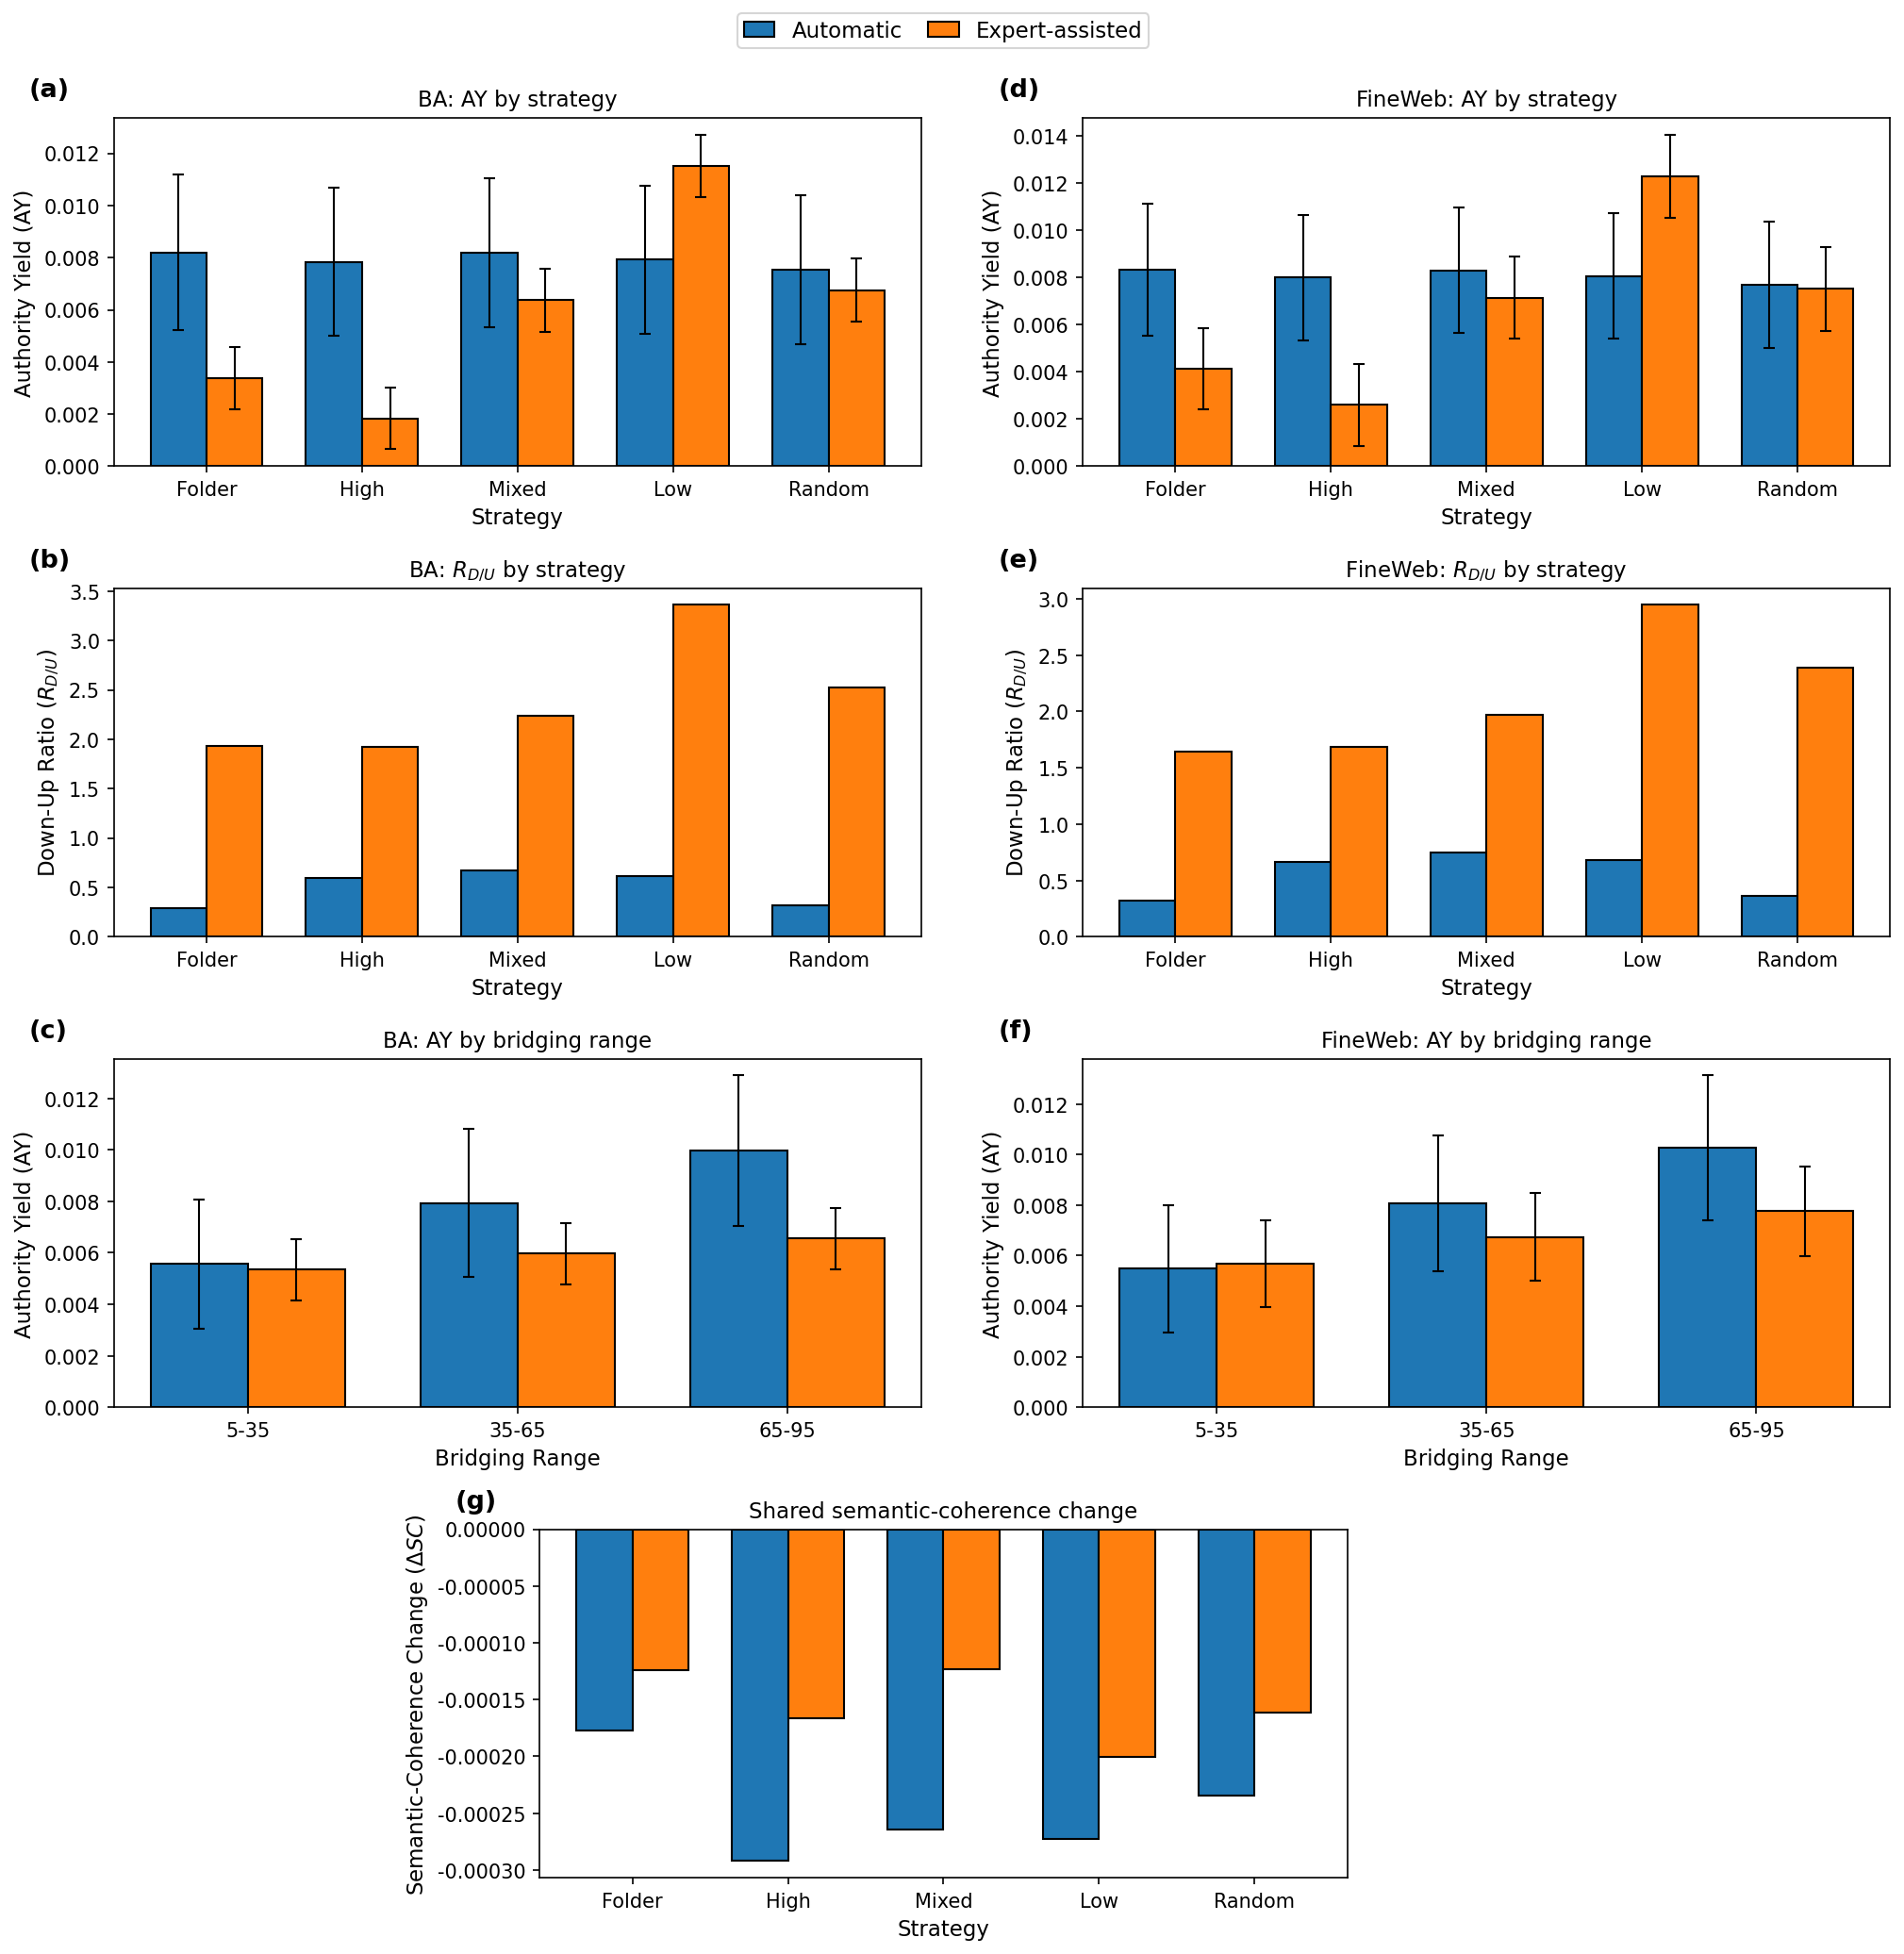

Saved combined figure to: webknograph_combined_metrics_and_semantic_coherence.png
Saved file:
webknograph_combined_metrics_and_semantic_coherence.png


In [20]:
# ==========================================
# WebKnoGraph combined figure generation
# Optimized publication-ready version
#
# Layout:
#
# First column = BA panels
# (a) BA Authority Yield by strategy, range 35-65
# (b) BA Down-Up Ratio by strategy, range 35-65
# (c) BA Authority Yield by bridging range, with AV error bars
#
# Second column = FineWeb panels
# (d) FineWeb Authority Yield by strategy, range 35-65
# (e) FineWeb Down-Up Ratio by strategy, range 35-65
# (f) FineWeb Authority Yield by bridging range, with AV error bars
#
# Bottom centered panel:
# (g) Shared Semantic-Coherence Change
#
# The Delta SC panel is centered below the two columns
# and has exactly the same size as the other panels.
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


# ==========================================
# 1. FILE PATHS
# ==========================================

AUTO_BA_PATH = "OVERALL_AVERAGES_TRACKER_AUTOMATIC_BA.csv"
AUTO_WWW_PATH = "OVERALL_AVERAGES_TRACKER_AUTOMATIC_WWW.csv"
EXPERT_BA_PATH = "OVERALL_AVERAGES_TRACKER_EXPERT_BA.csv"
EXPERT_WWW_PATH = "OVERALL_AVERAGES_TRACKER_EXPERT_WWW.csv"

SSA_PATH = "ssa_paper_strategy_values_repo_identity.csv"


# ==========================================
# 2. GLOBAL STYLE
# ==========================================

plt.rcParams.update(
    {
        "font.size": 11,
        "axes.labelsize": 11,
        "axes.titlesize": 11,
        "legend.fontsize": 11,
        "legend.title_fontsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    }
)

tab10 = plt.get_cmap("tab10")

AUTOMATIC_COLOR = tab10(0)
EXPERT_COLOR = tab10(1)

RANGE_ORDER = ["5-35", "35-65", "65-95"]
STRATEGY_ORDER = ["Folder", "High", "Mixed", "Low", "Random"]


# ==========================================
# 3. HELPER FUNCTIONS
# ==========================================


def normalize_strategy(s):
    s = str(s).strip().lower()

    if "folder" in s:
        return "Folder"
    if "high" in s:
        return "High"
    if "mixed" in s:
        return "Mixed"
    if "low" in s:
        return "Low"
    if "random" in s:
        return "Random"

    return str(s).title()


def normalize_range(r):
    r = str(r).strip()
    return r.replace("Range_", "")


def load_tracker(path, intervention_label):
    df = pd.read_csv(path).copy()

    df["StrategyLabel"] = df["Strategy"].apply(normalize_strategy)
    df["RangeLabel"] = df["Range"].apply(normalize_range)
    df["Intervention"] = intervention_label

    return df


def load_ssa_summary(path):
    """
    Expected columns:
    Regime
    Strategy
    Mean_Delta_SC
    """

    df = pd.read_csv(path).copy()

    required_cols = {"Regime", "Strategy", "Mean_Delta_SC"}
    missing = required_cols - set(df.columns)

    if missing:
        raise ValueError(
            f"SSA file is missing required columns: {missing}. "
            f"Available columns: {list(df.columns)}"
        )

    df["StrategyLabel"] = df["Strategy"].apply(normalize_strategy)

    df["Intervention"] = df["Regime"].map(
        {
            "automatic": "Automatic",
            "expert": "Expert-assisted",
            "Automatic": "Automatic",
            "Expert": "Expert-assisted",
            "Expert-assisted": "Expert-assisted",
        }
    )

    if df["Intervention"].isna().any():
        bad_values = df.loc[df["Intervention"].isna(), "Regime"].unique()
        raise ValueError(f"Unrecognized Regime values in SSA file: {bad_values}")

    df = df.rename(columns={"Mean_Delta_SC": "delta_ssa"})

    return df[["Intervention", "StrategyLabel", "delta_ssa"]]


def add_panel_label(ax, label):
    ax.text(
        -0.105,
        1.045,
        label,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        clip_on=False,
    )


def prepare_aggregate_by_range(df):
    out = (
        df.groupby("RangeLabel", as_index=False)
        .agg(
            Overall_Avg_AY=("Overall_Avg_AY", "mean"),
            Overall_Avg_AV=("Overall_Avg_AV", "mean"),
        )
        .set_index("RangeLabel")
        .reindex(RANGE_ORDER)
        .reset_index()
    )

    return out


def prepare_strategy_level(df, range_value="35-65"):
    out = (
        df[df["RangeLabel"] == range_value]
        .set_index("StrategyLabel")
        .reindex(STRATEGY_ORDER)
        .reset_index()
    )

    return out


def prepare_semantic_coherence(ssa_summary, intervention_label):
    out = (
        ssa_summary[ssa_summary["Intervention"] == intervention_label]
        .set_index("StrategyLabel")
        .reindex(STRATEGY_ORDER)
        .reset_index()
    )

    return out


# ==========================================
# 4. PANEL PLOTTING FUNCTIONS
# ==========================================


def plot_strategy_ay_panel(ax, auto_df, expert_df, panel_label, host_label):
    """
    Authority Yield by strategy for the representative 35-65 range.
    Includes Authority Volatility as error bars.
    """

    bar_width = 0.36
    x = np.arange(len(STRATEGY_ORDER))

    err_kw = dict(ecolor="black", elinewidth=1.0, capsize=3, capthick=1.0)

    auto_strategy = prepare_strategy_level(auto_df, range_value="35-65")
    expert_strategy = prepare_strategy_level(expert_df, range_value="35-65")

    bars_auto = ax.bar(
        x - bar_width / 2,
        auto_strategy["Overall_Avg_AY"].to_numpy(),
        width=bar_width,
        yerr=auto_strategy["Overall_Avg_AV"].to_numpy(),
        color=AUTOMATIC_COLOR,
        edgecolor="black",
        label="Automatic",
        error_kw=err_kw,
    )

    bars_expert = ax.bar(
        x + bar_width / 2,
        expert_strategy["Overall_Avg_AY"].to_numpy(),
        width=bar_width,
        yerr=expert_strategy["Overall_Avg_AV"].to_numpy(),
        color=EXPERT_COLOR,
        edgecolor="black",
        label="Expert-assisted",
        error_kw=err_kw,
    )

    ax.set_title(f"{host_label}: AY by strategy")
    ax.set_xticks(x)
    ax.set_xticklabels(STRATEGY_ORDER)
    ax.set_xlabel("Strategy", labelpad=4)
    ax.set_ylabel("Authority Yield (AY)")

    add_panel_label(ax, panel_label)

    return bars_auto, bars_expert


def plot_strategy_dur_panel(ax, auto_df, expert_df, panel_label, host_label):
    """
    Down-Up Ratio by strategy for the representative 35-65 range.
    """

    bar_width = 0.36
    x = np.arange(len(STRATEGY_ORDER))

    auto_strategy = prepare_strategy_level(auto_df, range_value="35-65")
    expert_strategy = prepare_strategy_level(expert_df, range_value="35-65")

    ax.bar(
        x - bar_width / 2,
        auto_strategy["Overall_Avg_DUR"].to_numpy(),
        width=bar_width,
        color=AUTOMATIC_COLOR,
        edgecolor="black",
    )

    ax.bar(
        x + bar_width / 2,
        expert_strategy["Overall_Avg_DUR"].to_numpy(),
        width=bar_width,
        color=EXPERT_COLOR,
        edgecolor="black",
    )

    ax.set_title(f"{host_label}: $R_{{D/U}}$ by strategy")
    ax.set_xticks(x)
    ax.set_xticklabels(STRATEGY_ORDER)
    ax.set_xlabel("Strategy", labelpad=4)
    ax.set_ylabel(r"Down-Up Ratio ($R_{D/U}$)")

    add_panel_label(ax, panel_label)


def plot_range_ay_panel(ax, auto_df, expert_df, panel_label, host_label):
    """
    Authority Yield across bridging ranges.
    Values are averaged across strategies.
    Includes Authority Volatility as error bars.
    """

    bar_width = 0.36
    x_range = np.arange(len(RANGE_ORDER))

    err_kw = dict(ecolor="black", elinewidth=1.0, capsize=3, capthick=1.0)

    auto_range = prepare_aggregate_by_range(auto_df)
    expert_range = prepare_aggregate_by_range(expert_df)

    ax.bar(
        x_range - bar_width / 2,
        auto_range["Overall_Avg_AY"].to_numpy(),
        width=bar_width,
        yerr=auto_range["Overall_Avg_AV"].to_numpy(),
        color=AUTOMATIC_COLOR,
        edgecolor="black",
        error_kw=err_kw,
    )

    ax.bar(
        x_range + bar_width / 2,
        expert_range["Overall_Avg_AY"].to_numpy(),
        width=bar_width,
        yerr=expert_range["Overall_Avg_AV"].to_numpy(),
        color=EXPERT_COLOR,
        edgecolor="black",
        error_kw=err_kw,
    )

    ax.set_title(f"{host_label}: AY by bridging range")
    ax.set_xticks(x_range)
    ax.set_xticklabels(RANGE_ORDER)
    ax.set_xlabel("Bridging Range", labelpad=4)
    ax.set_ylabel("Authority Yield (AY)")

    add_panel_label(ax, panel_label)


def plot_semantic_coherence_panel(ax, ssa_summary, panel_label):
    """
    Shared Semantic-Coherence Change panel.
    This is computed on the augmented site graph and is shared
    across BA and FineWeb host environments.
    """

    bar_width = 0.36
    x = np.arange(len(STRATEGY_ORDER))

    auto_sc = prepare_semantic_coherence(ssa_summary, "Automatic")
    expert_sc = prepare_semantic_coherence(ssa_summary, "Expert-assisted")

    ax.bar(
        x - bar_width / 2,
        auto_sc["delta_ssa"].to_numpy(),
        width=bar_width,
        color=AUTOMATIC_COLOR,
        edgecolor="black",
    )

    ax.bar(
        x + bar_width / 2,
        expert_sc["delta_ssa"].to_numpy(),
        width=bar_width,
        color=EXPERT_COLOR,
        edgecolor="black",
    )

    ax.set_title("Shared semantic-coherence change")
    ax.set_xticks(x)
    ax.set_xticklabels(STRATEGY_ORDER)
    ax.set_xlabel("Strategy", labelpad=4)
    ax.set_ylabel(r"Semantic-Coherence Change ($\Delta SC$)")
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.5f"))

    add_panel_label(ax, panel_label)


# ==========================================
# 5. COMBINED FIGURE
# ==========================================


def plot_combined_webknograph_figure(
    auto_ba,
    expert_ba,
    auto_www,
    expert_www,
    ssa_summary,
    output_file="webknograph_combined_metrics_and_semantic_coherence.png",
):
    """
    Creates one combined publication figure.

    First column:
    BA host environment panels.

    Second column:
    FineWeb host environment panels.

    Bottom:
    Shared Semantic-Coherence Change panel, centered and exactly the same size as the other panels.
    """

    # Optimized height:
    # 15.6 was visually too tall and created too much vertical whitespace.
    fig = plt.figure(figsize=(13.8, 14.3), dpi=150)

    # Optimized hspace:
    # 0.58 created too much space between panels.
    # 0.36 keeps titles, x-labels, and panel labels readable.
    gs = fig.add_gridspec(
        4, 2, height_ratios=[1.0, 1.0, 1.0, 1.0], hspace=0.35, wspace=0.20
    )

    # First column: BA
    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[1, 0])
    ax_c = fig.add_subplot(gs[2, 0])

    # Second column: FineWeb
    ax_d = fig.add_subplot(gs[0, 1])
    ax_e = fig.add_subplot(gs[1, 1])
    ax_f = fig.add_subplot(gs[2, 1])

    # Semantic-coherence panel starts as a full-row axis.
    # After layout calculation, it is resized to match panel (a).
    ax_g = fig.add_subplot(gs[3, :])

    bars_auto, bars_expert = plot_strategy_ay_panel(
        ax=ax_a,
        auto_df=auto_ba,
        expert_df=expert_ba,
        panel_label="(a)",
        host_label="BA",
    )

    plot_strategy_dur_panel(
        ax=ax_b,
        auto_df=auto_ba,
        expert_df=expert_ba,
        panel_label="(b)",
        host_label="BA",
    )

    plot_range_ay_panel(
        ax=ax_c,
        auto_df=auto_ba,
        expert_df=expert_ba,
        panel_label="(c)",
        host_label="BA",
    )

    plot_strategy_ay_panel(
        ax=ax_d,
        auto_df=auto_www,
        expert_df=expert_www,
        panel_label="(d)",
        host_label="FineWeb",
    )

    plot_strategy_dur_panel(
        ax=ax_e,
        auto_df=auto_www,
        expert_df=expert_www,
        panel_label="(e)",
        host_label="FineWeb",
    )

    plot_range_ay_panel(
        ax=ax_f,
        auto_df=auto_www,
        expert_df=expert_www,
        panel_label="(f)",
        host_label="FineWeb",
    )

    plot_semantic_coherence_panel(ax=ax_g, ssa_summary=ssa_summary, panel_label="(g)")

    # Global spacing.
    # Slightly larger top leaves room for the shared legend.
    plt.subplots_adjust(top=0.925, bottom=0.055, left=0.075, right=0.985)

    # Force final layout calculation before resizing the semantic-coherence panel.
    fig.canvas.draw()

    # Make semantic-coherence panel exactly the same width and height as a normal panel.
    ref_pos = ax_a.get_position()
    sc_pos = ax_g.get_position()

    new_width = ref_pos.width
    new_height = ref_pos.height

    new_x0 = 0.5 - new_width / 2
    new_y0 = sc_pos.y0

    ax_g.set_position([new_x0, new_y0, new_width, new_height])

    # Shared legend on top.
    fig.legend(
        handles=[bars_auto, bars_expert],
        labels=["Automatic", "Expert-assisted"],
        loc="upper center",
        bbox_to_anchor=(0.5, 0.982),
        ncol=2,
        frameon=True,
        handlelength=1.4,
        columnspacing=1.2,
        borderpad=0.3,
        labelspacing=0.3,
    )

    plt.savefig(output_file, bbox_inches="tight", pad_inches=0.14, dpi=300)
    plt.show()

    print(f"Saved combined figure to: {output_file}")


# ==========================================
# 6. LOAD DATA
# ==========================================

auto_ba = load_tracker(AUTO_BA_PATH, "Automatic")
auto_www = load_tracker(AUTO_WWW_PATH, "Automatic")

expert_ba = load_tracker(EXPERT_BA_PATH, "Expert-assisted")
expert_www = load_tracker(EXPERT_WWW_PATH, "Expert-assisted")

ssa_summary = load_ssa_summary(SSA_PATH)


# ==========================================
# 7. GENERATE FIGURE
# ==========================================

plot_combined_webknograph_figure(
    auto_ba=auto_ba,
    expert_ba=expert_ba,
    auto_www=auto_www,
    expert_www=expert_www,
    ssa_summary=ssa_summary,
    output_file="webknograph_combined_metrics_and_semantic_coherence.png",
)


# ==========================================
# 8. CONFIRM OUTPUT
# ==========================================

print("Saved file:")
print("webknograph_combined_metrics_and_semantic_coherence.png")